In [2]:
import pandas as pd

X_core = pd.read_csv('../data/har_features.csv')
y_core = pd.read_csv('../data/har_labels.csv')['activity']
groups_core = pd.read_csv('../data/har_groups.csv')['user']

print('X:', X_core.shape)
print('y:', y_core.shape)
print('groups:', groups_core.shape)

X: (5409, 24)
y: (5409,)
groups: (5409,)


In [3]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_core, y_core, groups_core))

X_train = X_core.iloc[train_idx]
X_test  = X_core.iloc[test_idx]
y_train = y_core.iloc[train_idx]
y_test  = y_core.iloc[test_idx]

print('train windows:', len(X_train))
print('test windows: ', len(X_test))

train windows: 4312
test windows:  1097


In [4]:
train_users = set(groups_core.iloc[train_idx])
test_users  = set(groups_core.iloc[test_idx])

print('users in train:', sorted(train_users))
print('users in test: ', sorted(test_users))
print('overlap:', train_users & test_users)   # must be empty

users in train: [1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 14, 15, 17, 19, 20, 21, 22, 23, 25, 26, 27, 29, 30]
users in test:  [9, 10, 16, 18, 24, 28]
overlap: set()


In [5]:
from sklearn.ensemble import RandomForestClassifier

# create the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# train it on the training data
clf.fit(X_train, y_train)

# predict on the held-out test users
y_pred = clf.predict(X_test)

print('done training and predicting')

done training and predicting


In [6]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f'subject-independent accuracy: {acc:.3f}')

subject-independent accuracy: 0.832


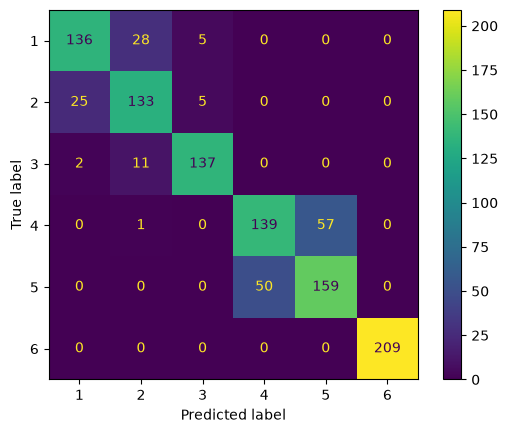

              precision    recall  f1-score   support

           1       0.83      0.80      0.82       169
           2       0.77      0.82      0.79       163
           3       0.93      0.91      0.92       150
           4       0.74      0.71      0.72       197
           5       0.74      0.76      0.75       209
           6       1.00      1.00      1.00       209

    accuracy                           0.83      1097
   macro avg       0.83      0.83      0.83      1097
weighted avg       0.83      0.83      0.83      1097



In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# the confusion matrix: rows = true activity, columns = predicted activity
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[1,2,3,4,5,6])
disp.plot()
plt.show()

# per-class precision/recall/f1
print(classification_report(y_test, y_pred))

In [8]:
from sklearn.model_selection import train_test_split

# Naive split: random rows, ignoring users
Xtr_naive, Xte_naive, ytr_naive, yte_naive = train_test_split(
    X_core, y_core, test_size=0.2, random_state=42
)

clf_naive = RandomForestClassifier(n_estimators=100, random_state=42)
clf_naive.fit(Xtr_naive, ytr_naive)
naive_acc = accuracy_score(yte_naive, clf_naive.predict(Xte_naive))

print(f'naive (leaky) random split accuracy:  {naive_acc:.3f}')
print(f'honest subject-independent accuracy:  0.832')

naive (leaky) random split accuracy:  0.963
honest subject-independent accuracy:  0.832


In [9]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 5-fold, splitting by user each time
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(clf, X_core, y_core, groups=groups_core, cv=gkf)

print('fold accuracies:', scores)
print(f'mean: {scores.mean():.3f}   std: {scores.std():.3f}')

fold accuracies: [0.91187384 0.89463956 0.92243767 0.84210526 0.86334257]
mean: 0.887   std: 0.030
